In [1]:
import numpy as np
import tensorflow.keras as keras
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()
IMAGE_DIMENSIONS = (x_train.shape[1], x_train.shape[2], x_train.shape[3])
labels = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]

In [3]:
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dropout, Dense
from keras.models import Sequential

In [4]:
def plot_curves(history, model_name):
    def plot_loss_curves(history, plot):
        plot.plot(history.history['loss'], label='Train Loss')
        plot.plot(history.history['val_loss'], label='Validation Loss')
        plot.title(f'{model_name}: Training & Validation Loss')
        plot.xlabel('Epoch')
        plot.ylabel('Mean Squared Error (Loss)')
        plot.legend()
        plot.grid(True)

    def plot_accuracy_curves(history, plot):
        plot.plot(history.history['accuracy'], label='Train Accuracy')
        plot.plot(history.history['val_accuracy'], label='Validation Accuracy')
        plot.title(f'{model_name}: Training & Validation Accuracy')
        plot.xlabel('Epoch')
        plot.ylabel('Accuracy')
        plot.legend()
        plot.grid(True)
    
    plt.figure(figsize=(5,5))
    plot_loss_curves(history, plt)
    plt.show()
    plt.figure(figsize=(5,5))
    plot_accuracy_curves(history, plt)
    plt.show()

## Basic CNN

In [5]:
basic_cnn_model = Sequential([
    keras.Input(shape=IMAGE_DIMENSIONS),
    # The convolution layer detects specific features of an image in every section of the image
    Conv2D(32, 3, padding='same', activation='relu'),
    # Pooling reduces the dimensions of the feature maps from the convolution layer
    MaxPooling2D((2,2)),

    # The number of filters (the first parameter of Conv2D) expand to account for different combinations 
    # of features in the deeper parts of the model
    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(10, activation = 'softmax') # Last dense layer has 10 units for the 10 types of labels
])

In [6]:
basic_cnn_model.compile(
    optimizer='adam',
    # Sparse categorical crossentropy is used when multiple labels are provided as 
    # integers, but not one-hot encoded
    loss = 'sparse_categorical_crossentropy', 
    metrics=['accuracy']
)
basic_cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# This cell will take about a few minutes to run. If you have more layers or epochs, it could run longer
history_basic_cnn = basic_cnn_model.fit(
    x_train,
    y_train,
    epochs = 10,
    validation_split = 0.1
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.4632 - loss: 1.8555 - val_accuracy: 0.5676 - val_loss: 1.2386
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.5964 - loss: 1.1495 - val_accuracy: 0.6230 - val_loss: 1.0893
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.6496 - loss: 1.0025 - val_accuracy: 0.6432 - val_loss: 1.0209
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.6866 - loss: 0.8982 - val_accuracy: 0.6600 - val_loss: 0.9835
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.7162 - loss: 0.8117 - val_accuracy: 0.6624 - val_loss: 0.9969
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.7409 - loss: 0.7430 - val_accuracy: 0.6880 - val_loss: 0.9665
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 22s 15ms/step - accuracy: 0.7638 - loss: 0.6752 - val_accuracy: 0.7010 - val_loss: 0.9360
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.7883 -

In [8]:
basic_train_loss = history_basic_cnn.history['loss']
basic_train_accuracy = history_basic_cnn.history['accuracy']
basic_validation_loss = history_basic_cnn.history['val_loss']
basic_validation_accuracy = history_basic_cnn.history['val_accuracy']
basic_test_loss, basic_test_accuracy = basic_cnn_model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6757 - loss: 1.1412


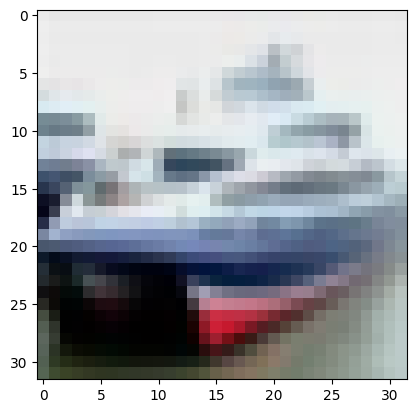

In [9]:
plt.imshow(x_test[1])

In [10]:
basic_cnn_predictions = basic_cnn_model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [11]:
print(f"Basic CNN Model")
print(f"Final Train Accuracy: {basic_train_accuracy[len(basic_train_accuracy)-1]:.3f}, Final Train Loss: {basic_train_loss[len(basic_train_loss)-1]:.3f}")
print(f"Final Validation Accuracy: {basic_validation_accuracy[len(basic_validation_accuracy)-1]:.3f}, Final Validation Loss: {basic_validation_loss[len(basic_validation_loss)-1]:.3f}")
print(f"Test Accuracy: {basic_test_accuracy:.3f}, Test Loss: {basic_test_loss:.3f}")
print(f"Example Prediction: {labels[np.argmax(basic_cnn_predictions[1])]}, Actual = {labels[y_test[1][0]]}")

Basic CNN Model
Final Train Accuracy: 0.824, Final Train Loss: 0.510
Final Validation Accuracy: 0.693, Final Validation Loss: 1.080
Test Accuracy: 0.676, Test Loss: 1.141
Example Prediction: ship, Actual = ship


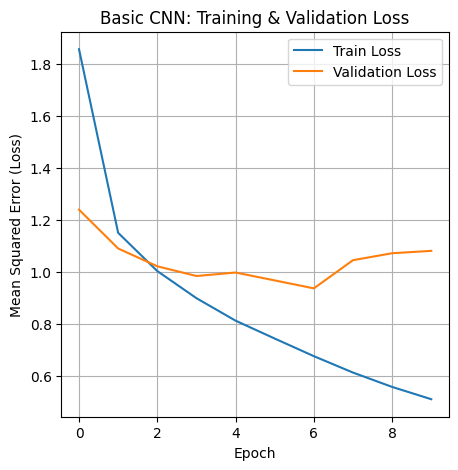

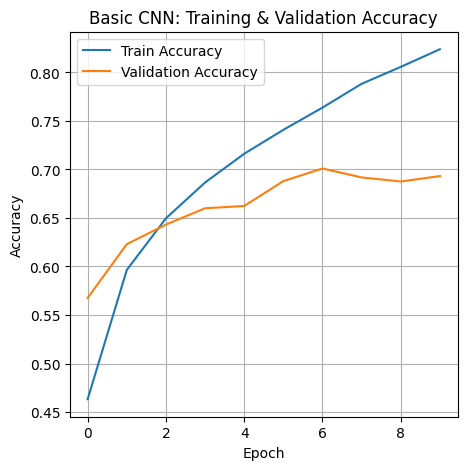

In [ ]:
plot_curves(history_basic_cnn, "Basic CNN")
# Ideally, the train and validation curves should converge smoothly. The validation curve here is unstable and crosses the train curve, 
# meaning the model is unstable and likely overfitting.

## CNN with More Layers

In [ ]:
more_cnn_model = Sequential([
    keras.Input(shape=IMAGE_DIMENSIONS),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(256, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(10, activation = 'softmax')
])

In [ ]:
more_cnn_model.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy', 
    metrics=['accuracy']
)
more_cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 653,386 (2.49 MB)

 Trainable params: 653,386 (2.49 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history_more_cnn = more_cnn_model.fit(
    x_train,
    y_train,
    epochs = 10,
    validation_split = 0.1
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 28s 19ms/step - accuracy: 0.4651 - loss: 1.6232 - val_accuracy: 0.5728 - val_loss: 1.2070
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.6035 - loss: 1.1270 - val_accuracy: 0.6466 - val_loss: 1.0130
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.6571 - loss: 0.9858 - val_accuracy: 0.6738 - val_loss: 0.9683
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.6892 - loss: 0.8927 - val_accuracy: 0.6702 - val_loss: 0.9613
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.7180 - loss: 0.8120 - val_accuracy: 0.6856 - val_loss: 0.9302
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.7404 - loss: 0.7489 - val_accuracy: 0.6924 - val_loss: 0.9026
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 18ms/step - accuracy: 0.7588 - loss: 0.6923 - val_accuracy: 0.6878 - val_loss: 0.9848
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 25s 18ms/step - accuracy: 0.7754 -

In [16]:
more_train_loss = history_more_cnn.history['loss']
more_train_accuracy = history_more_cnn.history['accuracy']
more_validation_loss = history_more_cnn.history['val_loss']
more_validation_accuracy = history_more_cnn.history['val_accuracy']
more_test_loss, more_test_accuracy = more_cnn_model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6942 - loss: 1.0419


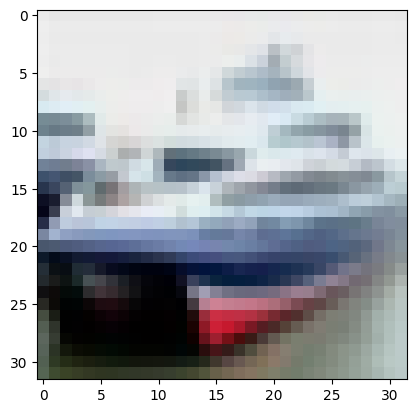

In [17]:
plt.imshow(x_test[1])

In [18]:
more_cnn_predictions = more_cnn_model.predict(x_test)
print(f"CNN Model with More Layers")
print(f"Final Train Accuracy: {more_train_accuracy[len(more_train_accuracy)-1]:.3f}, Final Train Loss: {more_train_loss[len(more_train_loss)-1]:.3f}")
print(f"Final Validation Accuracy: {more_validation_accuracy[len(more_validation_accuracy)-1]:.3f}, Final Validation Loss: {more_validation_loss[len(more_validation_loss)-1]:.3f}")
print(f"Test Accuracy: {more_test_accuracy:.3f}, Test Loss: {more_test_loss:.3f}")
print(f"Example Prediction: {labels[np.argmax(more_cnn_predictions[1])]}, Actual = {labels[y_test[1][0]]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
CNN Model with More Layers
Final Train Accuracy: 0.806, Final Train Loss: 0.555
Final Validation Accuracy: 0.711, Final Validation Loss: 1.016
Test Accuracy: 0.694, Test Loss: 1.042
Example Prediction: ship, Actual = ship


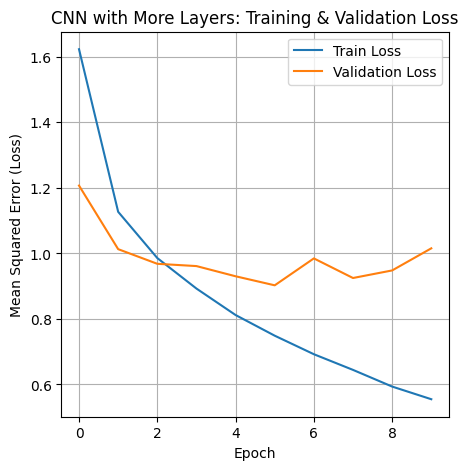

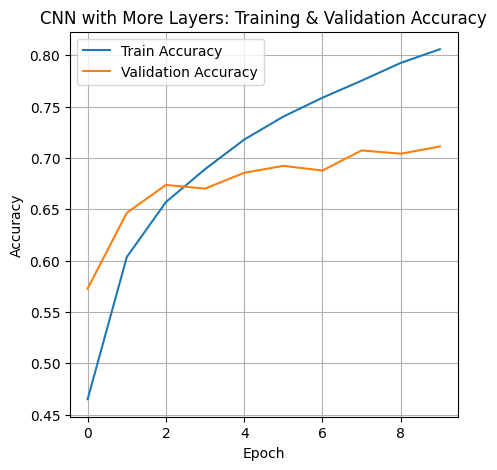

In [ ]:
plot_curves(history_more_cnn, "CNN with More Layers")
# The curves here are even more unstable than the basic CNN. The results are also worse, so adding more layers isn't better here.

## CNN with More Epochs

In [20]:
epoch_cnn_model = Sequential([
    keras.Input(shape=IMAGE_DIMENSIONS),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dense(10, activation = 'softmax')
])

In [21]:
epoch_cnn_model.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy', 
    metrics=['accuracy']
)
epoch_cnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
history_epoch_cnn = epoch_cnn_model.fit(
    x_train,
    y_train,
    epochs = 20,
    validation_split = 0.1
)

Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 21s 14ms/step - accuracy: 0.4653 - loss: 1.7029 - val_accuracy: 0.5484 - val_loss: 1.2486
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.6025 - loss: 1.1272 - val_accuracy: 0.5950 - val_loss: 1.1632
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.6589 - loss: 0.9775 - val_accuracy: 0.6370 - val_loss: 1.0405
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.6947 - loss: 0.8738 - val_accuracy: 0.6478 - val_loss: 1.0474
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.7265 - loss: 0.7904 - val_accuracy: 0.6950 - val_loss: 0.9389
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.7561 - loss: 0.7053 - val_accuracy: 0.7024 - val_loss: 0.9560
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.7775 - loss: 0.6380 - val_accuracy: 0.6846 - val_loss: 1.0029
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.7997 -

In [23]:
epoch_train_loss = history_epoch_cnn.history['loss']
epoch_train_accuracy = history_epoch_cnn.history['accuracy']
epoch_validation_loss = history_epoch_cnn.history['val_loss']
epoch_validation_accuracy = history_epoch_cnn.history['val_accuracy']
epoch_test_loss, epoch_test_accuracy = epoch_cnn_model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6751 - loss: 1.7258


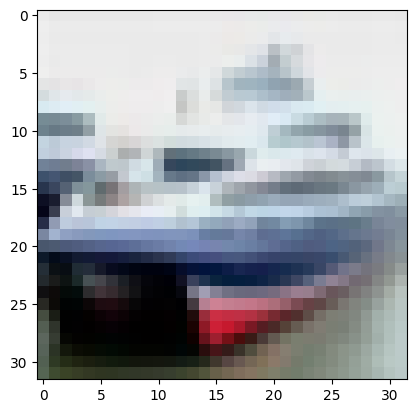

In [24]:
plt.imshow(x_test[1])

In [25]:
epoch_cnn_predictions = epoch_cnn_model.predict(x_test)
print(f"CNN Model with More Epochs")
print(f"Final Train Accuracy: {epoch_train_accuracy[len(epoch_train_accuracy)-1]:.3f}, Final Train Loss: {epoch_train_loss[len(epoch_train_loss)-1]:.3f}")
print(f"Final Validation Accuracy: {epoch_validation_accuracy[len(epoch_validation_accuracy)-1]:.3f}, Final Validation Loss: {epoch_validation_loss[len(epoch_validation_loss)-1]:.3f}")
print(f"Test Accuracy: {epoch_test_accuracy:.3f}, Test Loss: {epoch_test_loss:.3f}")
print(f"Example Prediction: {labels[np.argmax(epoch_cnn_predictions[1])]}, Actual = {labels[y_test[1][0]]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
CNN Model with More Epochs
Final Train Accuracy: 0.902, Final Train Loss: 0.315
Final Validation Accuracy: 0.684, Final Validation Loss: 1.708
Test Accuracy: 0.675, Test Loss: 1.726
Example Prediction: ship, Actual = ship


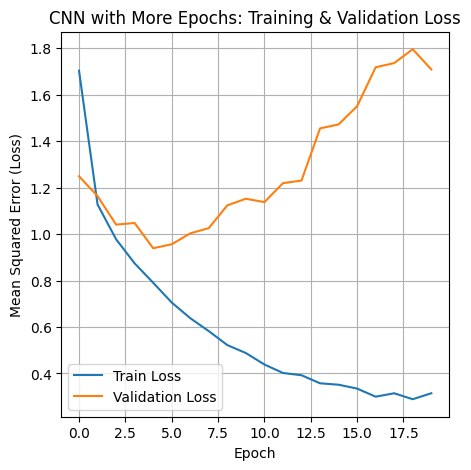

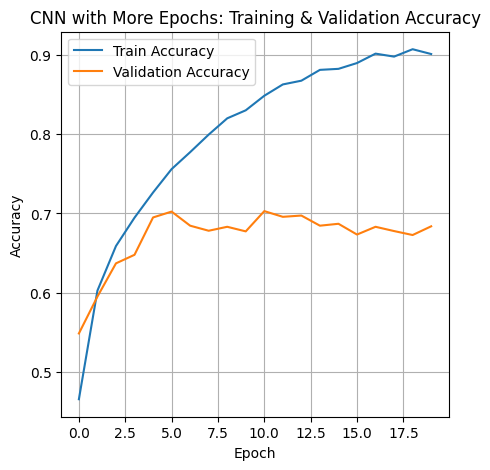

In [ ]:
plot_curves(history_epoch_cnn, "CNN with More Epochs")
# While the resulting accuracies are much better than the basic model, the curves are very unstable 
# and the test accuracy is similar to the basic model. So that means 20 epochs could be too many.

## CNN with Dropout

In [27]:
dropout_cnn_model = Sequential([
    keras.Input(shape=IMAGE_DIMENSIONS),
    Conv2D(32, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(64, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, 3, padding='same', activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.25),
    Dense(10, activation = 'softmax')
])

In [28]:
dropout_cnn_model.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy', 
    metrics=['accuracy']
)
dropout_cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 620,362 (2.37 MB)

 Trainable params: 620,362 (2.37 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
history_dropout_cnn = dropout_cnn_model.fit(
    x_train,
    y_train,
    epochs = 10,
    validation_split = 0.1
)

Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 13ms/step - accuracy: 0.4331 - loss: 1.7411 - val_accuracy: 0.5270 - val_loss: 1.3441
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.5559 - loss: 1.2618 - val_accuracy: 0.5734 - val_loss: 1.2034
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 23s 16ms/step - accuracy: 0.6030 - loss: 1.1294 - val_accuracy: 0.6134 - val_loss: 1.1113
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.6385 - loss: 1.0319 - val_accuracy: 0.6578 - val_loss: 0.9915
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.6637 - loss: 0.9605 - val_accuracy: 0.6516 - val_loss: 0.9994
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.6845 - loss: 0.8965 - val_accuracy: 0.6816 - val_loss: 0.9572
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 14ms/step - accuracy: 0.7038 - loss: 0.8489 - val_accuracy: 0.6768 - val_loss: 0.9954
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - accuracy: 0.7226 -

In [30]:
dropout_train_loss = history_dropout_cnn.history['loss']
dropout_train_accuracy = history_dropout_cnn.history['accuracy']
dropout_validation_loss = history_dropout_cnn.history['val_loss']
dropout_validation_accuracy = history_dropout_cnn.history['val_accuracy']
dropout_test_loss, dropout_test_accuracy = dropout_cnn_model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6661 - loss: 1.0630


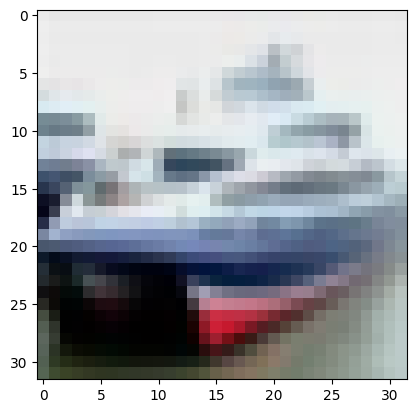

In [31]:
plt.imshow(x_test[1])

In [32]:
dropout_cnn_predictions = dropout_cnn_model.predict(x_test)
print(f"CNN Model with Dropout")
print(f"Final Train Accuracy: {dropout_train_accuracy[len(dropout_train_accuracy)-1]:.3f}, Final Train Loss: {dropout_train_loss[len(dropout_train_loss)-1]:.3f}")
print(f"Final Validation Accuracy: {dropout_validation_accuracy[len(dropout_validation_accuracy)-1]:.3f}, Final Validation Loss: {dropout_validation_loss[len(dropout_validation_loss)-1]:.3f}")
print(f"Test Accuracy: {dropout_test_accuracy:.3f}, Test Loss: {dropout_test_loss:.3f}")
print(f"Example Prediction: {labels[np.argmax(dropout_cnn_predictions[1])]}, Actual = {labels[y_test[1][0]]}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
CNN Model with Dropout
Final Train Accuracy: 0.747, Final Train Loss: 0.721
Final Validation Accuracy: 0.684, Final Validation Loss: 1.011
Test Accuracy: 0.666, Test Loss: 1.063
Example Prediction: ship, Actual = ship


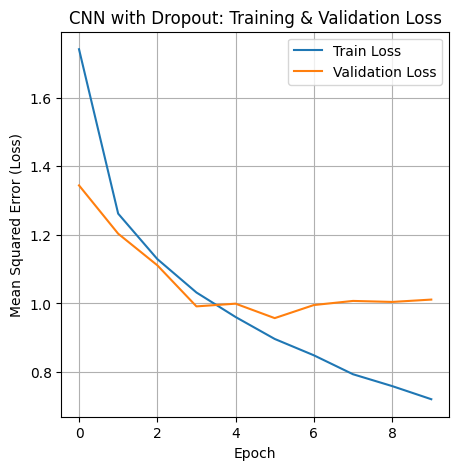

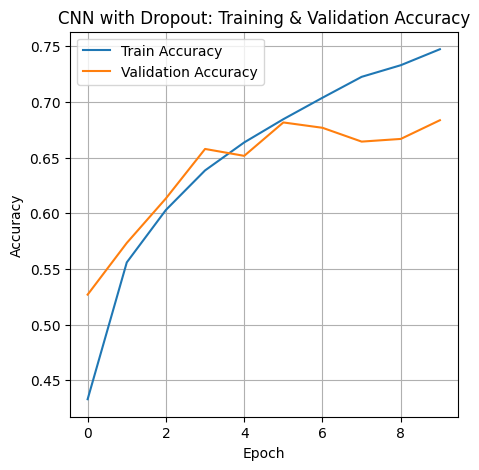

In [ ]:
plot_curves(history_dropout_cnn, "CNN with Dropout")
# While the results are about the same as the basic model, the curves are more stable.
# Adding more dropout layers, perhaps between the convolution and pooling layers could help.
# Doing this with more epochs could yield some better results.